In [107]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

In [109]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [110]:
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head(3)

Shape   : (7043, 21)
Columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [111]:
print(df.dtypes)
print(df.isnull().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Mo

In [112]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (7043, 21)


In [113]:
df.drop(columns=["customerID"], inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [114]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].dtype)

float64


In [115]:
df.dropna(inplace=True)

print("Missing values:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Missing values: 0
Dataset shape: (7032, 20)


In [116]:
df["churned"] = (df["Churn"] == "Yes").astype(int)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churned
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [117]:
df.drop(columns=["Churn"], inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churned
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [118]:
print("Churn Rate:", df["churned"].mean())
print("Churned Customers:", df["churned"].sum())
print("Active Customers:", (df["churned"] == 0).sum())

Churn Rate: 0.26578498293515357
Churned Customers: 1869
Active Customers: 5163


In [119]:
binary_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

In [120]:
for col in binary_cols:
    df[col + "_enc"] = (df[col] == "Yes").astype(int)

In [121]:
df[[col + "_enc" for col in binary_cols]].head()

,Partner_enc,Dependents_enc,PhoneService_enc,PaperlessBilling_enc,MultipleLines_enc,OnlineSecurity_enc,OnlineBackup_enc,DeviceProtection_enc,TechSupport_enc,StreamingTV_enc,StreamingMovies_enc
0,1,0,0,1,0,0,1,0,0,0,0
1,0,0,1,0,0,1,0,1,0,0,0
2,0,0,1,1,0,1,1,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,0
4,0,0,1,1,0,0,0,0,0,0,0


In [122]:
df["gender_enc"] = (df["gender"] == "Male").astype(int)

df[["gender", "gender_enc"]].head()

,gender,gender_enc
0,Female,0
1,Male,1
2,Male,1
3,Male,1
4,Female,0


In [123]:
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

df["contract_enc"] = df["Contract"].map(contract_map)

df[["Contract", "contract_enc"]].head()

,Contract,contract_enc
0,Month-to-month,0
1,One year,1
2,Month-to-month,0
3,One year,1
4,Month-to-month,0


In [124]:
internet_map = {
    "No": 0,
    "DSL": 1,
    "Fiber optic": 2
}

df["internet_enc"] = df["InternetService"].map(internet_map)

df[["InternetService", "internet_enc"]].head()

,InternetService,internet_enc
0,DSL,1
1,DSL,1
2,DSL,1
3,DSL,1
4,Fiber optic,2


In [125]:
le = LabelEncoder()

df["payment_enc"] = le.fit_transform(df["PaymentMethod"])

In [126]:
print("Final Shape:", df.shape)

df.head()

Final Shape: (7032, 35)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,OnlineSecurity_enc,OnlineBackup_enc,DeviceProtection_enc,TechSupport_enc,StreamingTV_enc,StreamingMovies_enc,gender_enc,contract_enc,internet_enc,payment_enc
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,0,1,0,0,0,0,0,0,1,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1,0,1,0,0,0,1,1,1,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,1,1,0,0,0,0,1,0,1,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,1,0,1,1,0,0,1,1,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,0,0,0,0,0,0,0,0,2,2


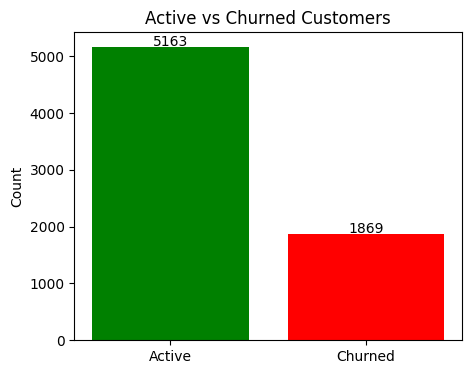

In [127]:
churn_counts = df["churned"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["Active", "Churned"], churn_counts.values, color=["green", "red"])
plt.title("Active vs Churned Customers")
plt.ylabel("Count")

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 20, str(v), ha="center")

plt.show()

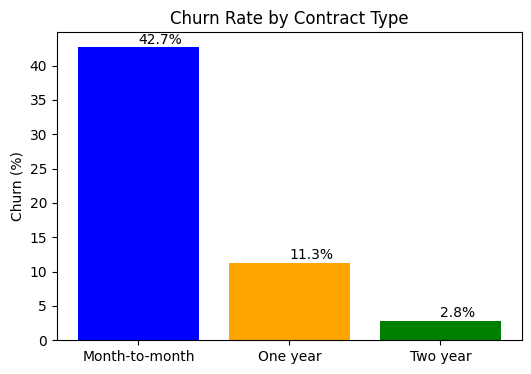

In [128]:
contract_churn = df.groupby("Contract")["churned"].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(contract_churn.index, contract_churn.values, color=["blue","orange","green"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn (%)")

for i, v in enumerate(contract_churn.values):
    plt.text(i, v + 0.5, f"{v:.1f}%")

plt.show()

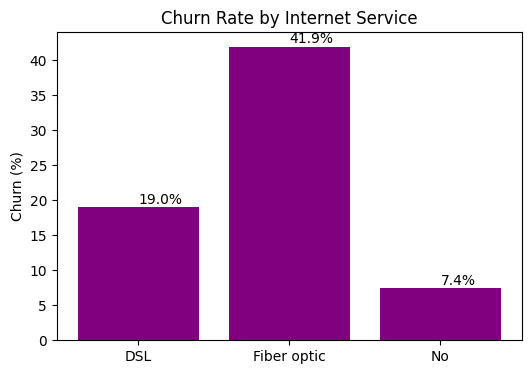

In [129]:
internet_churn = df.groupby("InternetService")["churned"].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(internet_churn.index, internet_churn.values, color="purple")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn (%)")

for i, v in enumerate(internet_churn.values):
    plt.text(i, v + 0.5, f"{v:.1f}%")

plt.show()

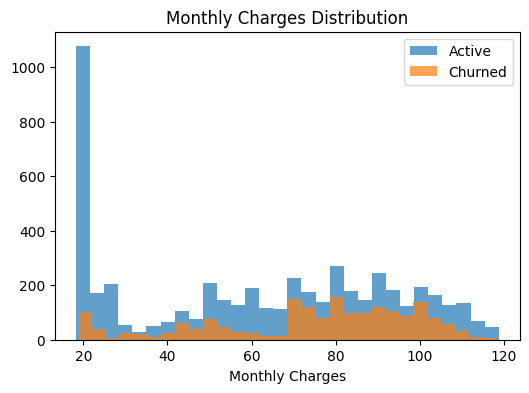

In [130]:
plt.figure(figsize=(6,4))

plt.hist(df[df["churned"] == 0]["MonthlyCharges"],
         bins=30, alpha=0.7, label="Active")

plt.hist(df[df["churned"] == 1]["MonthlyCharges"],
         bins=30, alpha=0.7, label="Churned")

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.legend()

plt.show()

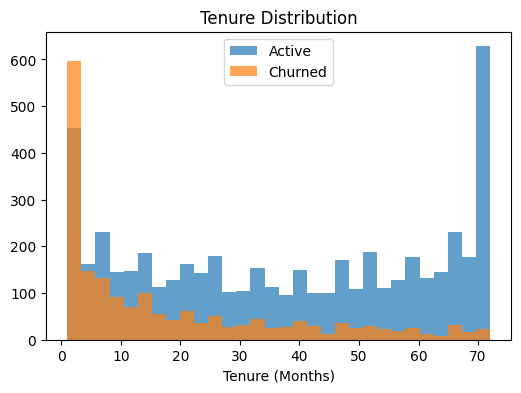

In [131]:
plt.figure(figsize=(6,4))

plt.hist(df[df["churned"] == 0]["tenure"],
         bins=30, alpha=0.7, label="Active")

plt.hist(df[df["churned"] == 1]["tenure"],
         bins=30, alpha=0.7, label="Churned")

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.legend()

plt.show()

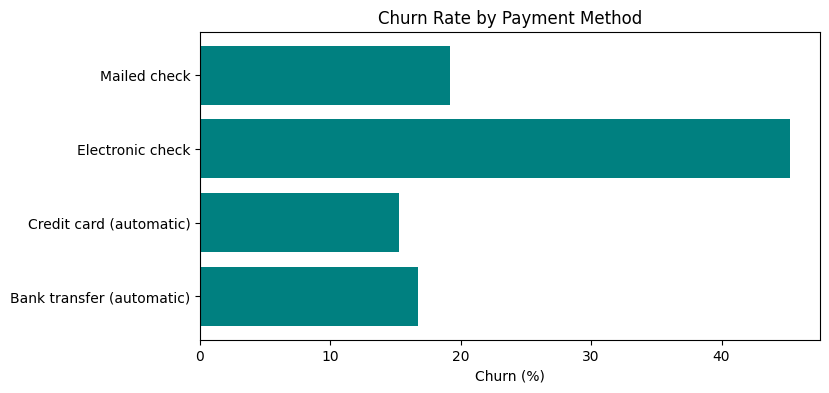

In [132]:
payment_churn = df.groupby("PaymentMethod")["churned"].mean() * 100

plt.figure(figsize=(8,4))
plt.barh(payment_churn.index, payment_churn.values, color="teal")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn (%)")

plt.show()

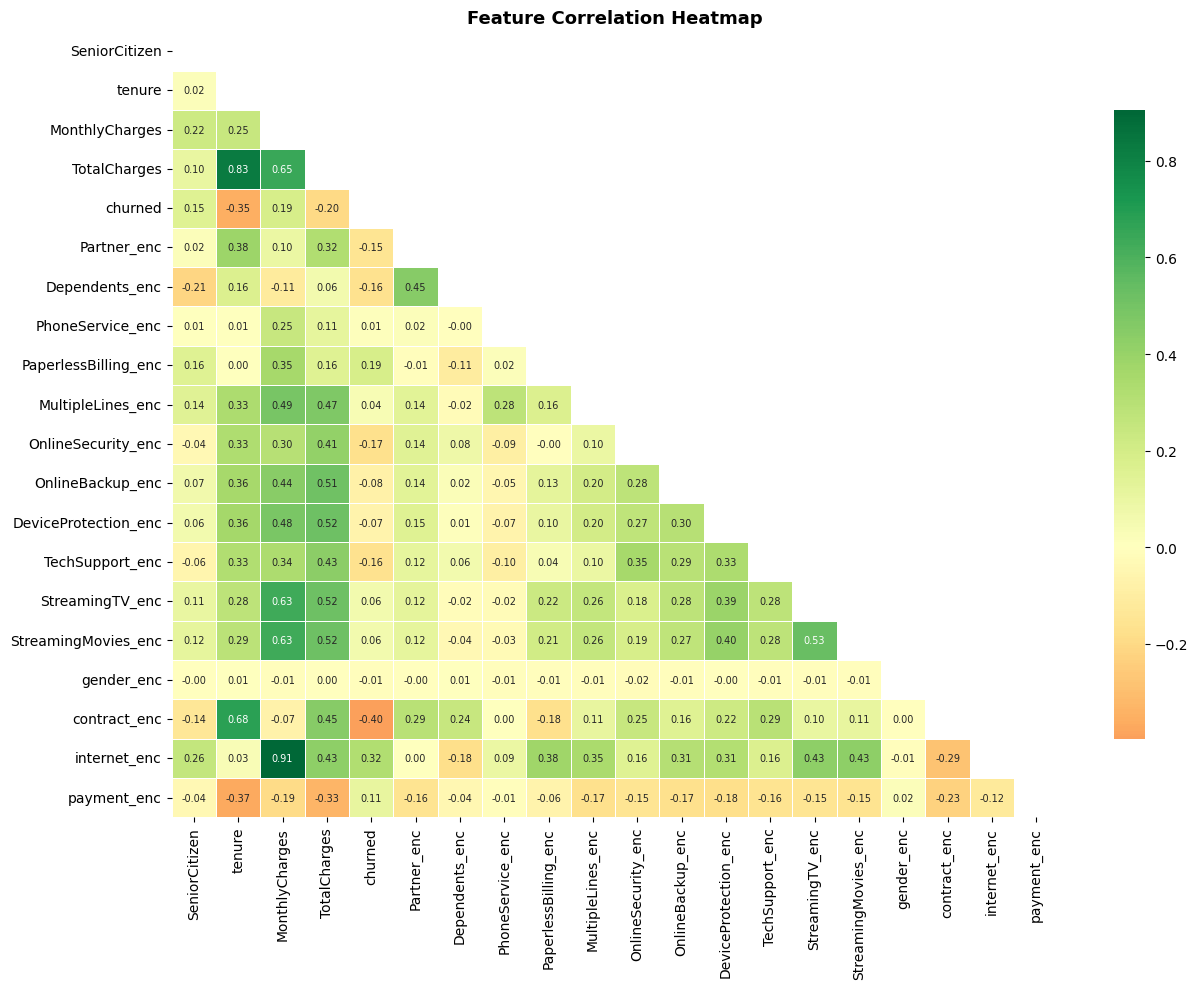

In [133]:
numeric_df = df.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(13, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

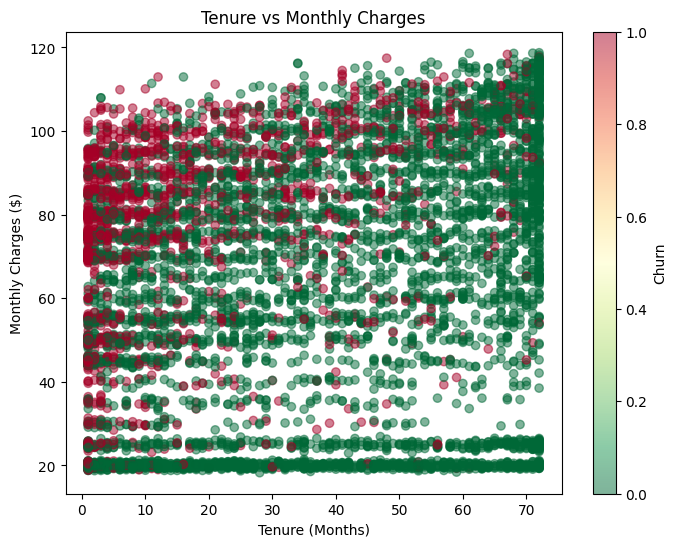

In [134]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["tenure"],
    df["MonthlyCharges"],
    c=df["churned"],
    cmap="RdYlGn_r",
    alpha=0.5
)

plt.colorbar(label="Churn")
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")

plt.savefig("outputs/03_tenure_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [135]:
seg_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "contract_enc",
    "internet_enc",
    "gender_enc",
    "SeniorCitizen",
    "payment_enc"
]

X_seg = df[seg_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

print(X_scaled.shape)

(7032, 8)


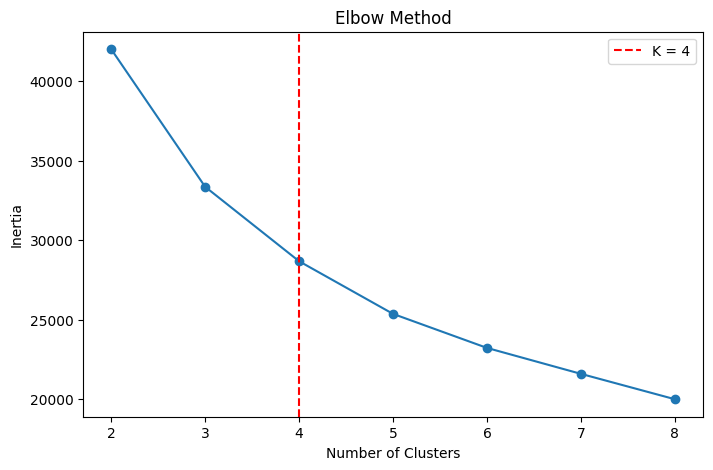

In [136]:
inertias = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,9), inertias, marker="o")
plt.axvline(x=4, color="red", linestyle="--", label="K = 4")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.legend()

plt.savefig("outputs/04_elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [137]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(X_scaled)

df[["segment"]].head()

,segment
0,0
1,0
2,0
3,3
4,0


In [138]:
seg_churn = df.groupby("segment")["churned"].mean().rank()

name_pool = {
    4: "High-Value Loyal",
    3: "Regular Users",
    2: "Casual Subscribers",
    1: "At-Risk Customers"
}

df["segment_name"] = df["segment"].map(
    {i: name_pool[int(r)] for i, r in seg_churn.items()}
)

In [139]:
segment_summary = df.groupby("segment_name")["churned"].agg(
    Count="count",
    Churn_Rate="mean"
)

print(segment_summary)

                    Count  Churn_Rate
segment_name                         
At-Risk Customers    1701    0.072898
Casual Subscribers   1838    0.112078
High-Value Loyal      937    0.489861
Regular Users        2556    0.422535


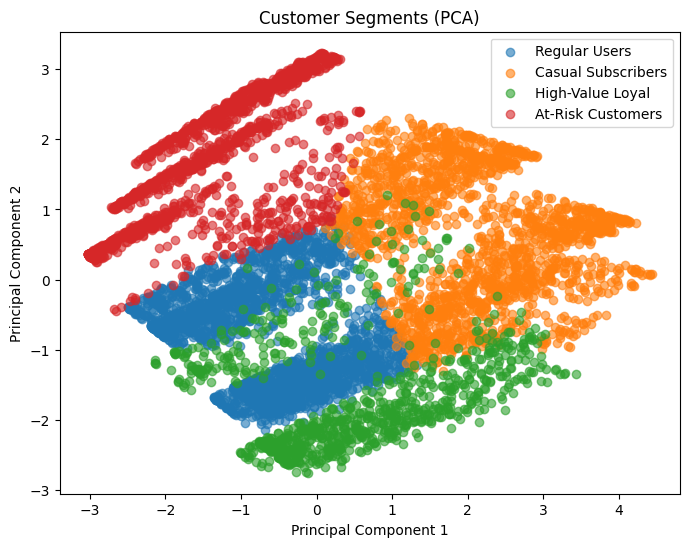

In [140]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for i in sorted(df["segment"].unique()):
    plt.scatter(
        X_pca[df["segment"] == i, 0],
        X_pca[df["segment"] == i, 1],
        label=df[df["segment"] == i]["segment_name"].iloc[0],
        alpha=0.6
    )

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.savefig("outputs/05_pca_segments.png", dpi=300, bbox_inches="tight")
plt.show()

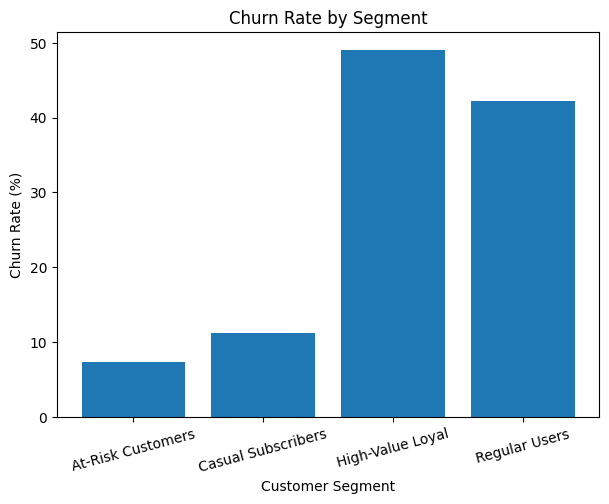

In [141]:
segment_churn = df.groupby("segment_name")["churned"].mean() * 100

plt.figure(figsize=(7,5))

plt.bar(segment_churn.index, segment_churn.values)

plt.title("Churn Rate by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)

plt.savefig("outputs/06_segment_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [142]:
feature_cols = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "SeniorCitizen", "contract_enc", "internet_enc",
    "gender_enc", "payment_enc", "segment",
    "Partner_enc", "Dependents_enc", "PhoneService_enc",
    "PaperlessBilling_enc", "OnlineSecurity_enc",
    "OnlineBackup_enc", "DeviceProtection_enc",
    "TechSupport_enc", "StreamingTV_enc", "StreamingMovies_enc"
]

X = df[feature_cols]
y = df["churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (5625, 19)
Testing Samples: (1407, 19)


In [143]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [144]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric="logloss"
    )
}
print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'])


In [145]:
results = {}
roc_data = {}

for name, model in models.items():

    if name == "Logistic Regression":
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[name] = {
        "auc": auc,
        "pred": y_pred,
        "proba": y_proba
    }

    roc_data[name] = (fpr, tpr, auc)

    print(f"{name}: {auc:.4f}")
best_name = max(results, key=lambda x: results[x]["auc"])

print("Best Model:", best_name)
print("AUC Score:", round(results[best_name]["auc"], 4))

Logistic Regression: 0.8343
Decision Tree: 0.8121
Random Forest: 0.8358
XGBoost: 0.8322
Best Model: Random Forest
AUC Score: 0.8358


In [146]:
metrics = []

for name in results:
    y_pred = results[name]["pred"]

    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": results[name]["auc"]
    })

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.set_index("Model")

metrics_df.round(4)
metrics_df.round(4).to_csv("outputs/model_metrics.csv")

In [147]:
for name in results:
    print(f"\n{name}")
    print(classification_report(
        y_test,
        results[name]["pred"],
        target_names=["Active", "Churned"]
    ))


Logistic Regression
              precision    recall  f1-score   support

      Active       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407


Decision Tree
              precision    recall  f1-score   support

      Active       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407


Random Forest
              precision    recall  f1-score   support

      Active       0.90      0.75      0.82      1033
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80

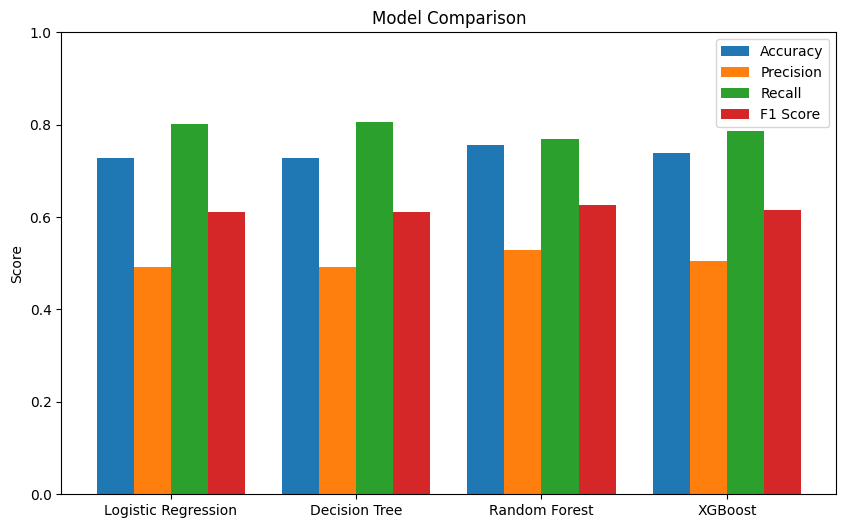

In [148]:
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics_df))
width = 0.2

plt.figure(figsize=(10,6))

for i, metric in enumerate(metric_names):
    plt.bar(x + i*width, metrics_df[metric], width, label=metric)

plt.xticks(x + width*1.5, metrics_df.index)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()

plt.savefig("outputs/05_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

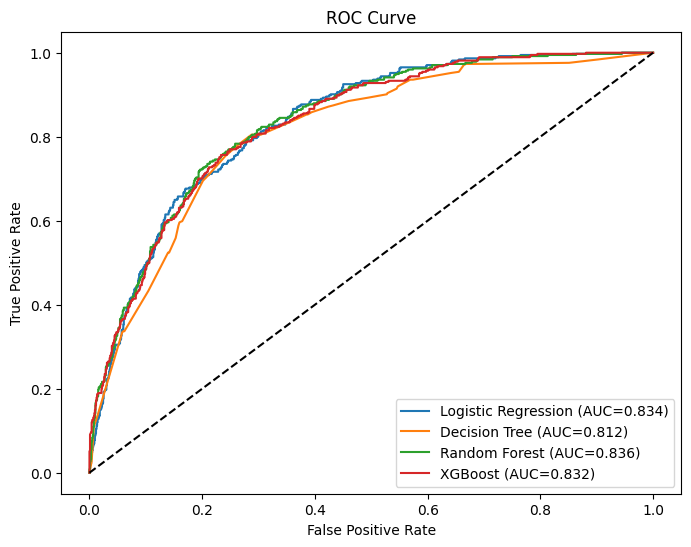

In [149]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("outputs/06_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

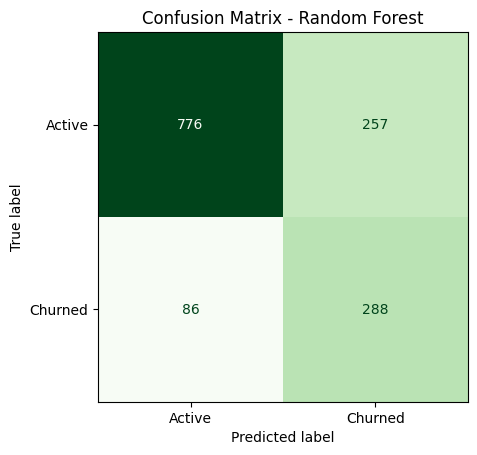

In [150]:
cm = confusion_matrix(y_test, results[best_name]["pred"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Active", "Churned"]
)

disp.plot(cmap="Greens", colorbar=False)

plt.title(f"Confusion Matrix - {best_name}")
plt.savefig("outputs/07_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

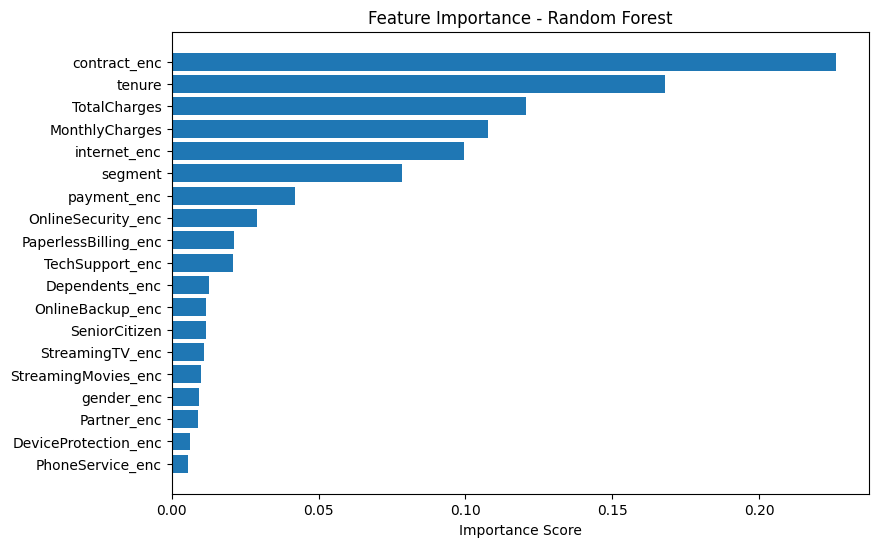

In [151]:
rf_model = models["Random Forest"]

fi = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(9,6))
plt.barh(fi.index, fi.values)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")

plt.savefig("outputs/08_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

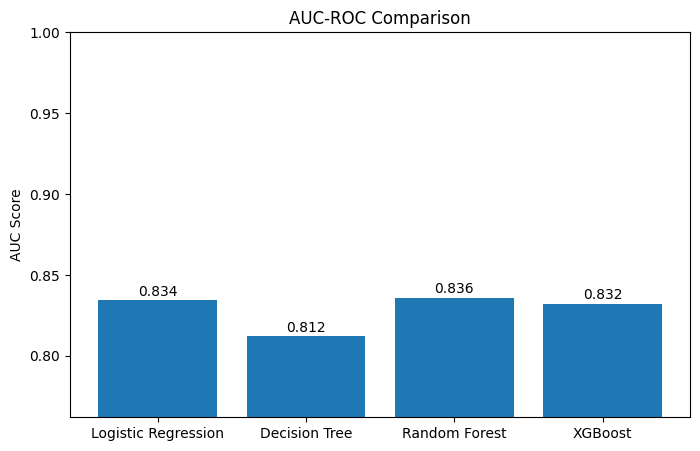

In [152]:
names = list(results.keys())
aucs = [results[n]["auc"] for n in names]

plt.figure(figsize=(8,5))
bars = plt.bar(names, aucs)

plt.ylim(min(aucs)-0.05, 1)
plt.title("AUC-ROC Comparison")
plt.ylabel("AUC Score")

for bar, val in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{val:.3f}",
             ha="center")

plt.savefig("outputs/09_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [153]:
print("IBM TELCO CHURN PROJECT")
print(f"Dataset rows   : {len(df):,}")
print(f"Churn rate     : {df['churned'].mean():.1%}")
print(f"Segments found : {optimal_k}")
print(f"Best model     : {best_name}")
print(f"Best AUC       : {results[best_name]['auc']:.4f}")

IBM TELCO CHURN PROJECT
Dataset rows   : 7,032
Churn rate     : 26.6%
Segments found : 4
Best model     : Random Forest
Best AUC       : 0.8358
